# Tutorial 5 : Exponential Smoothing

The data set `ausunemp.csv` contains monthly data on the Australian unemployment rate, starting in January 1990.

### Load all Python Modules

In [1]:
%reset -f

import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import seaborn           as sns
import numpy             as np

from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from statsmodels.tsa.stattools   import adfuller

### Graph Settings

In [2]:
pd.plotting.register_matplotlib_converters()
sns.mpl.rc('figure',figsize=(16, 6))
pd.set_option('display.float_format', lambda x: '%.2f' % x) # makes numbas nice

### Load Data

In [3]:
df = pd.read_csv('ausunemp.csv')
df.index = pd.date_range(start='1990-01-01', periods=355, freq='M')
df.drop(['month'], axis=1, inplace=True)

df = df.rename(columns={"Unemployment rate (percentage; source: ABS)": "data"})

In [4]:
df.head()

,unemp,m1,m2,m3,m4,m5,m6,m7,m8,m9,m10,m11,m12
1990-01-31,6.70,1,0,0,0,0,0,0,0,0,0,0,0
1990-02-28,7.10,0,1,0,0,0,0,0,0,0,0,0,0
1990-03-31,6.50,0,0,1,0,0,0,0,0,0,0,0,0
1990-04-30,6.30,0,0,0,1,0,0,0,0,0,0,0,0
1990-05-31,6.50,0,0,0,0,1,0,0,0,0,0,0,0


In [5]:
df.index

DatetimeIndex(['1990-01-31', '1990-02-28', '1990-03-31', '1990-04-30',
               '1990-05-31', '1990-06-30', '1990-07-31', '1990-08-31',
               '1990-09-30', '1990-10-31',
               ...
               '2018-10-31', '2018-11-30', '2018-12-31', '2019-01-31',
               '2019-02-28', '2019-03-31', '2019-04-30', '2019-05-31',
               '2019-06-30', '2019-07-31'],
              dtype='datetime64[ns]', length=355, freq='M')

### (a). Holt-Winters Method

**Forecast the unemployment rate pattern for each month over the next five years, using the Holt–Winters smoothing method.**

If the series is stationary, the MA and Moving std should be hovering around some constant value. We can investigate this using the `plot_rollin()` function:

In [6]:
### calculating rolling mean
df['z_data'] = (df['unemp'] - df.unemp.rolling(window=4).mean()) / df.unemp.rolling(window=12).std()
df['zp_data'] = df['z_data'] - df['z_data'].shift(1)

def plot_rolling(df):
    fig, ax = plt.subplots(3,figsize=(12, 9))
    ax[0].scatter(df.index, df.unemp, color='c', label='raw data')
    ax[0].plot(df.unemp.rolling(window=4).mean(), color='b', label="moving avergae");
    ax[0].plot(df.unemp.rolling(window=4).std(), color='r', label="moving std");
    ax[0].legend()

    ax[1].scatter(df.index, df.z_data, color='c', label="de-trended data")
    ax[1].plot(df.z_data.rolling(window=4).mean(), color='b', label="moving aveage");
    ax[1].plot(df.z_data.rolling(window=4).std(), color='r', label="moving std");
    ax[1].legend()

    ax[2].scatter(df.index, df.zp_data, color='c', label="1 lag differenced de-trended data")
    ax[2].plot(df.zp_data.rolling(window=4).mean(), color='b', label="moving average");
    ax[2].plot(df.zp_data.rolling(window=4).std(), color='r', label="moving std");
    ax[2].legend()

    plt.tight_layout()
    fig.autofmt_xdate()

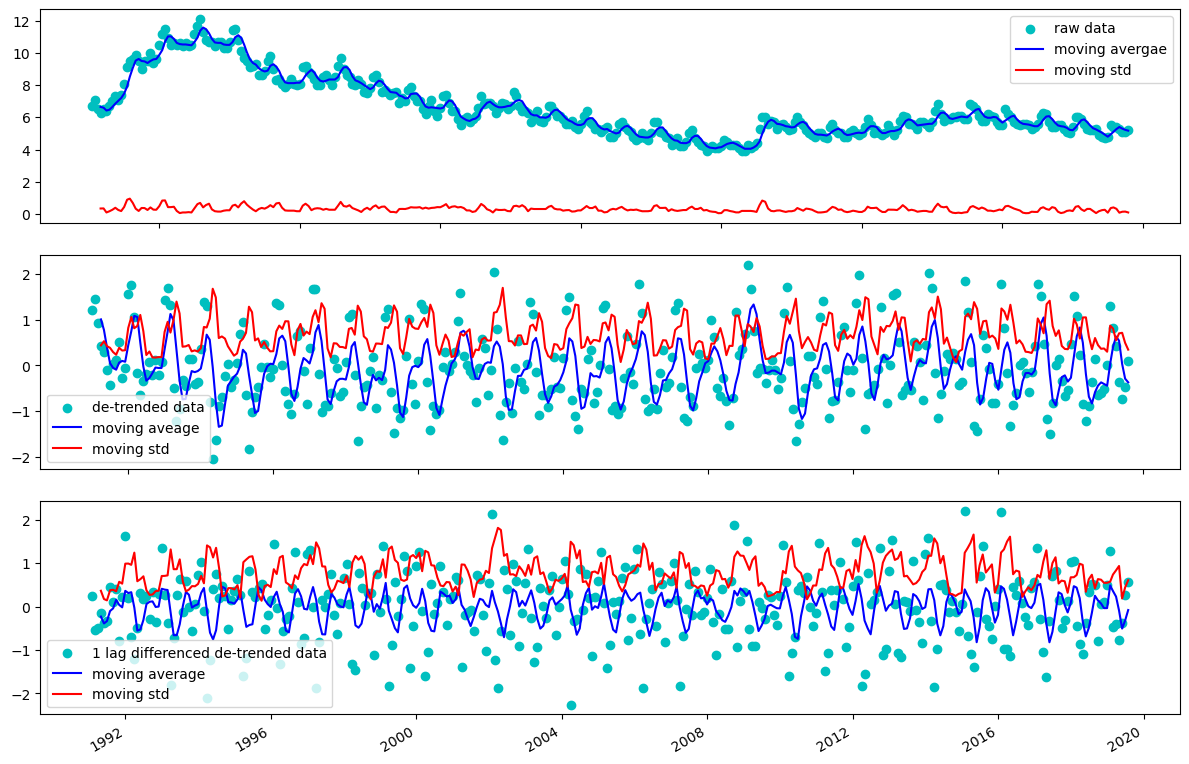

In [7]:
plot_rolling(df)

Running an ADF test using AIC to auto determine the max lag terms:

In [8]:
print(" > Is the data stationary ?")
dftest = adfuller(df.unemp.dropna(), autolag='AIC')
print("Test statistic = {:.3f}".format(dftest[0]))
print("P-value = {:.3f}".format(dftest[1]))
print("Critical values :")
for k, v in dftest[4].items():
  print("\t{}: {} - The data is {} stationary with {}% confidence".format(k, v, "not" if v<dftest[0] else "", 100-int(k[:-1])))
    
print("\n > Is the de-trended data stationary ?")
dftest = adfuller(df.z_data.dropna(), autolag='AIC')
print("Test statistic = {:.3f}".format(dftest[0]))
print("P-value = {:.3f}".format(dftest[1]))
print("Critical values :")
for k, v in dftest[4].items():
  print("\t{}: {} - The data is {} stationary with {}% confidence".format(k, v, "not" if v<dftest[0] else "", 100-int(k[:-1])))
    
print("\n > Is the 1-lag differenced de-trended data stationary ?")
dftest = adfuller(df.zp_data.dropna(), autolag='AIC')
print("Test statistic = {:.3f}".format(dftest[0]))
print("P-value = {:.3f}".format(dftest[1]))
print("Critical values :")
for k, v in dftest[4].items():
  print("\t{}: {} - The data is {} stationary with {}% confidence".format(k, v, "not" if v<dftest[0] else "", 100-int(k[:-1])))

 > Is the data stationary ?
Test statistic = -2.553
P-value = 0.103
Critical values :
	1%: -3.449673193310592 - The data is not stationary with 99% confidence
	5%: -2.8700533746644323 - The data is not stationary with 95% confidence
	10%: -2.5713055939491403 - The data is not stationary with 90% confidence

 > Is the de-trended data stationary ?
Test statistic = -4.633
P-value = 0.000
Critical values :
	1%: -3.4505694423906546 - The data is  stationary with 99% confidence
	5%: -2.8704469462727795 - The data is  stationary with 95% confidence
	10%: -2.5715154495841017 - The data is  stationary with 90% confidence

 > Is the 1-lag differenced de-trended data stationary ?
Test statistic = -6.252
P-value = 0.000
Critical values :
	1%: -3.4504451681828194 - The data is  stationary with 99% confidence
	5%: -2.870392380216117 - The data is  stationary with 95% confidence
	10%: -2.571486353732897 - The data is  stationary with 90% confidence


###### Simple exponential Smoothing Model (no trend)

In [9]:
model_simple = SimpleExpSmoothing(np.asarray(df['unemp']), initialization_method='estimated')
model_simple._index = pd.to_datetime(df.index)

fit_simple = model_simple.fit(optimized=True)
fore_simple = fit_simple.forecast(60)

print(fit_simple.summary())

                       SimpleExpSmoothing Model Results                       
Dep. Variable:                  endog   No. Observations:                  355
Model:             SimpleExpSmoothing   SSE                             45.330
Optimized:                       True   AIC                           -726.643
Trend:                           None   BIC                           -718.899
Seasonal:                        None   AICC                          -726.529
Seasonal Periods:                None   Date:                 Thu, 20 Aug 2026
Box-Cox:                        False   Time:                         22:01:43
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            1.0000000                alpha                 True
initial_level              6.6994907                

In [10]:
fore_simple

array([5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2,
       5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2,
       5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2,
       5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2,
       5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2])

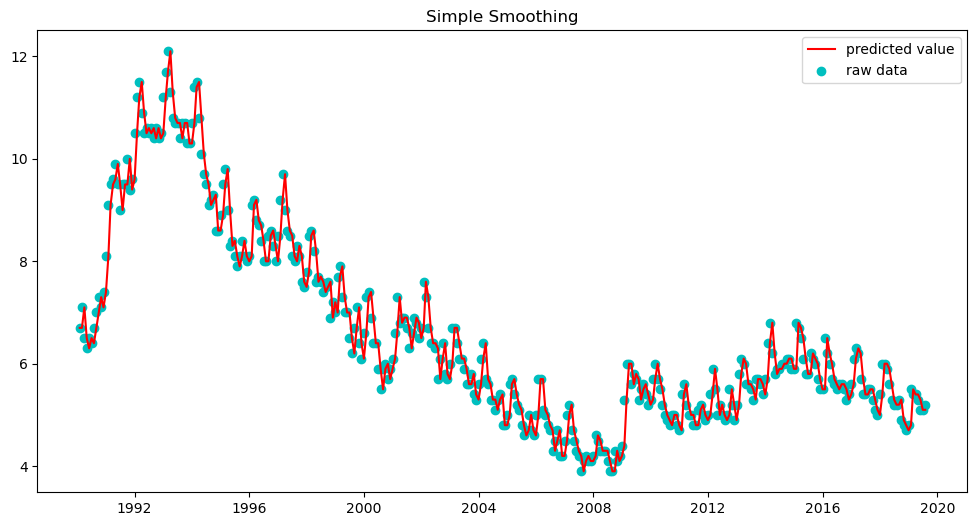

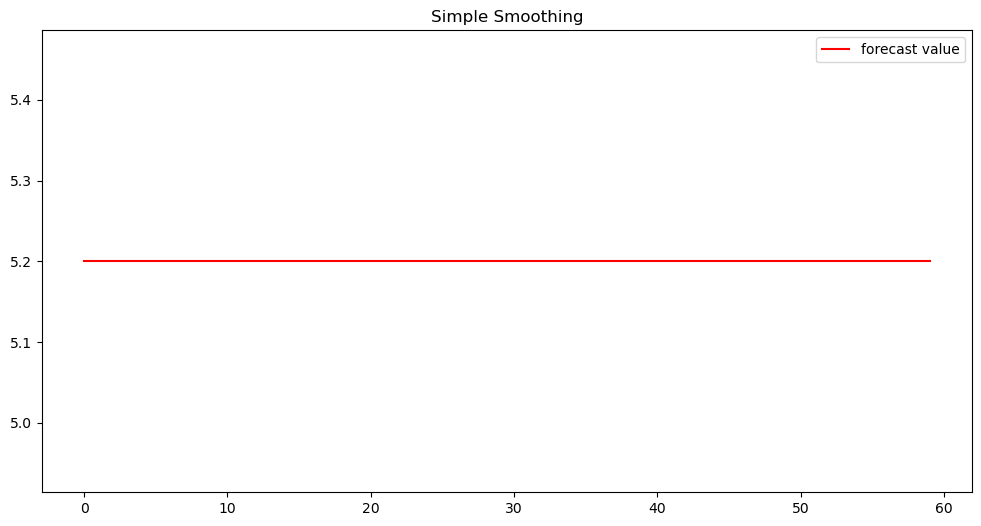

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df.index, fit_simple.fittedvalues, label="predicted value", color='r')
ax.scatter(df.index, df.unemp, color='c', label='raw data')

plt.title("Simple Smoothing")    
plt.legend();

fig1 = plt.subplots(figsize=(12, 6))
plt.plot(np.arange(0,60), fore_simple, label="forecast value", color='r')
plt.title("Simple Smoothing")    
plt.legend();

###### Hotl's linear trend smoothing

In [12]:
model_Holt_1 = Holt(np.asarray(df['unemp']), initialization_method="estimated")
model_Holt_1._index = pd.to_datetime(df.index)

fit_Holt_1  = model_Holt_1.fit(optimized=True)
fore_Holt_1 = fit_Holt_1.forecast(60)

print(fit_Holt_1.summary())

                              Holt Model Results                              
Dep. Variable:                  endog   No. Observations:                  355
Model:                           Holt   SSE                             45.324
Optimized:                       True   AIC                           -722.693
Trend:                       Additive   BIC                           -707.204
Seasonal:                        None   AICC                          -722.451
Seasonal Periods:                None   Date:                 Thu, 20 Aug 2026
Box-Cox:                        False   Time:                         22:01:44
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            1.0000000                alpha                 True
smoothing_trend           1.0453e-14                

In [13]:
fore_Holt_1

array([5.1957627 , 5.1915254 , 5.18728811, 5.18305081, 5.17881351,
       5.17457621, 5.17033892, 5.16610162, 5.16186432, 5.15762703,
       5.15338973, 5.14915243, 5.14491513, 5.14067784, 5.13644054,
       5.13220324, 5.12796594, 5.12372865, 5.11949135, 5.11525405,
       5.11101676, 5.10677946, 5.10254216, 5.09830486, 5.09406757,
       5.08983027, 5.08559297, 5.08135567, 5.07711838, 5.07288108,
       5.06864378, 5.06440649, 5.06016919, 5.05593189, 5.05169459,
       5.0474573 , 5.04322   , 5.0389827 , 5.0347454 , 5.03050811,
       5.02627081, 5.02203351, 5.01779622, 5.01355892, 5.00932162,
       5.00508432, 5.00084703, 4.99660973, 4.99237243, 4.98813513,
       4.98389784, 4.97966054, 4.97542324, 4.97118595, 4.96694865,
       4.96271135, 4.95847405, 4.95423676, 4.94999946, 4.94576216])

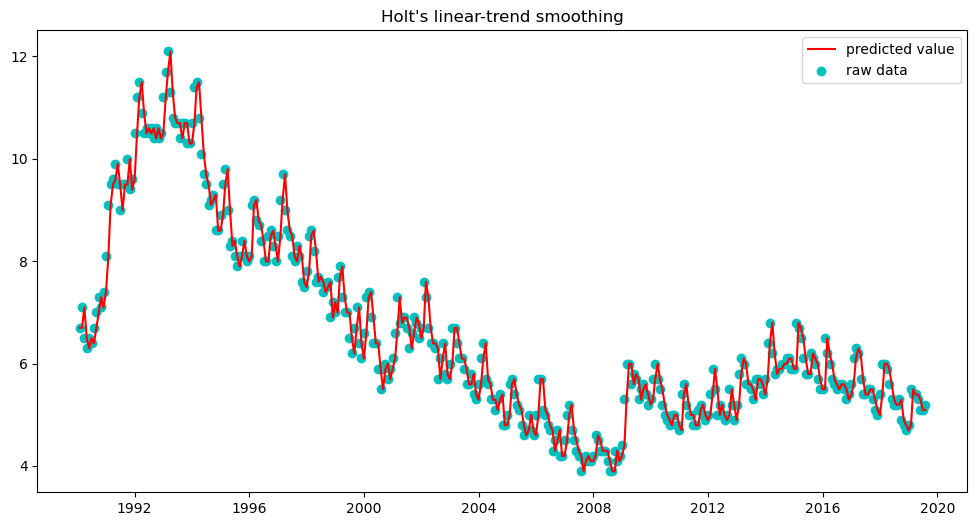

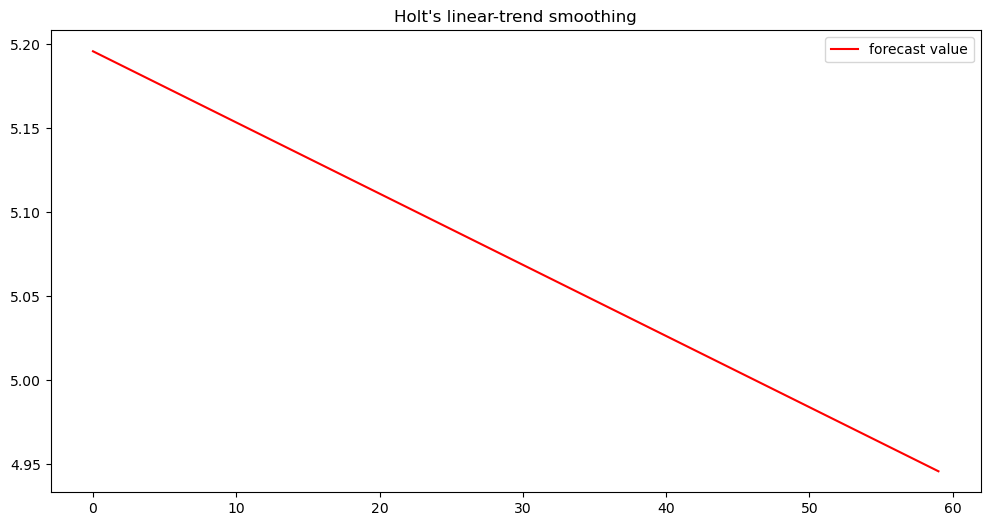

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, fit_Holt_1.fittedvalues, color='r', label='predicted value')
ax.scatter(df.index, df.unemp, color='c', label='raw data')

plt.title("Holt's linear-trend smoothing")
plt.legend();

fig2 = plt.subplots(figsize=(12, 6))
plt.plot(np.arange(0,60), fore_Holt_1, label="forecast value", color='r')
plt.title("Holt's linear-trend smoothing")    
plt.legend();

### (b). Gardner-McKenzie Method

###### Holt's Damped trend smoothing
**Now forecast the unemployment rate pattern for each month over the next five years, using the Gardner–McKenzie method.**

###### Use the multiplactive verion, unless the data has been logged bfore, otherwise use additive

In [15]:
model_Holt_2 = ExponentialSmoothing(np.asarray(df['unemp']),
                                    trend='mul', 
                                    seasonal=None, 
                                    initialization_method="estimated") 

model_Damp_2 = ExponentialSmoothing(np.asarray(df['unemp']), 
                                    trend='mul', 
                                    seasonal=None, 
                                    damped_trend = True, 
                                    initialization_method="estimated")
model_Holt_2._index = pd.to_datetime(df.index)
model_Damp_2._index = pd.to_datetime(df.index)

fit_Holt_2 = model_Holt_2.fit()
fit_Damp_2 = model_Damp_2.fit()
print(fit_Holt_2.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                    endog   No. Observations:                  355
Model:             ExponentialSmoothing   SSE                             45.270
Optimized:                         True   AIC                           -723.111
Trend:                   Multiplicative   BIC                           -707.622
Seasonal:                          None   AICC                          -722.870
Seasonal Periods:                  None   Date:                 Thu, 20 Aug 2026
Box-Cox:                          False   Time:                         22:01:44
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            1.0000000                alpha                 True
smoothing_trend             0.0000

In [16]:
print(fit_Damp_2.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                    endog   No. Observations:                  355
Model:             ExponentialSmoothing   SSE                             44.980
Optimized:                         True   AIC                           -723.394
Trend:                   Multiplicative   BIC                           -704.034
Seasonal:                          None   AICC                          -723.071
Seasonal Periods:                  None   Date:                 Thu, 20 Aug 2026
Box-Cox:                          False   Time:                         22:01:44
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            1.0000000                alpha                 True
smoothing_trend           7.5791e-

In [17]:
fore_Holt_2 = fit_Holt_2.forecast(60)
fore_Damp_2 = fit_Damp_2.forecast(60)

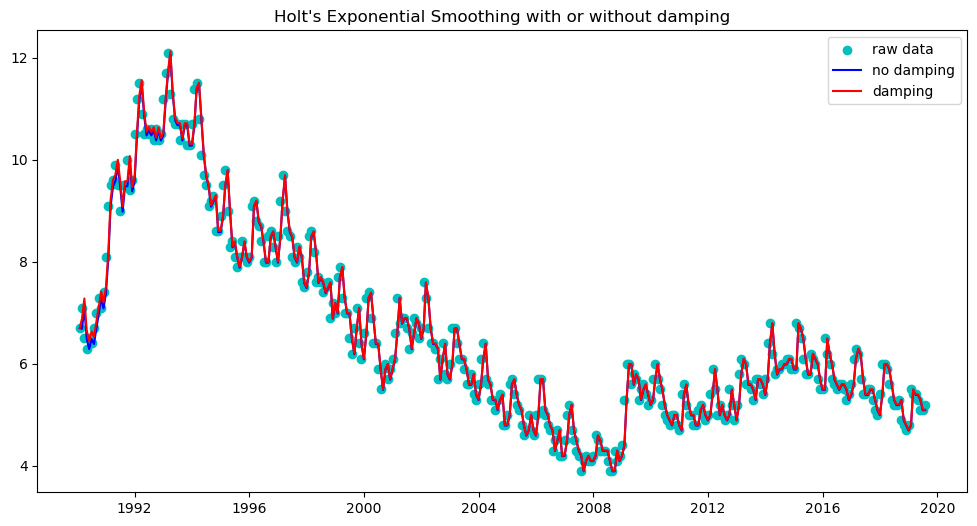

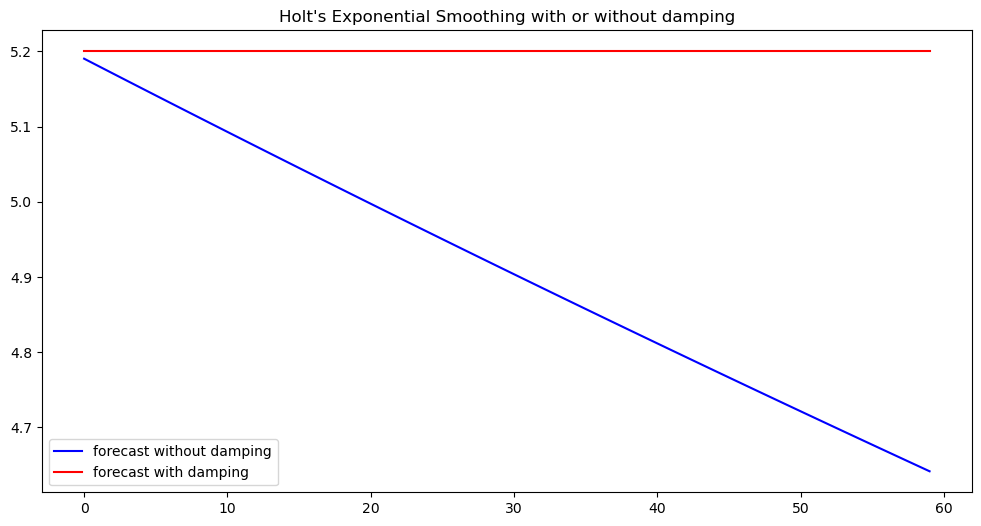

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(df.index, df.unemp, c='c', label='raw data')
ax.plot(df.index, fit_Holt_2.fittedvalues, color='b', label="no damping")
ax.plot(df.index, fit_Damp_2.fittedvalues, color='r', label="damping")

plt.title("Holt's Exponential Smoothing with or without damping") 
plt.legend()

fig2 = plt.subplots(figsize=(12, 6))
plt.plot(np.arange(0,60), fore_Holt_2, label="forecast without damping", color='b')
plt.plot(np.arange(0,60), fore_Damp_2, label="forecast with damping", color='r')
plt.title("Holt's Exponential Smoothing with or without damping")    
plt.legend();

###### Holt-Winters Seasonal Smoothing (with and without damping)

In [19]:
model_season_Holt = ExponentialSmoothing(np.asarray(df['unemp']), 
                                         trend="mul", 
                                         seasonal="mul", 
                                         seasonal_periods=12, 
                                         initialization_method="estimated")
model_season_Damp = ExponentialSmoothing(np.asarray(df['unemp']),
                                         trend="mul", 
                                         seasonal="mul", 
                                         seasonal_periods=12, 
                                         damped_trend=True, 
                                         initialization_method="estimated")
model_season_Holt._index = pd.to_datetime(df.index)
model_season_Damp._index = pd.to_datetime(df.index)

fit_season_Holt = model_season_Holt.fit()
fit_season_Damp = model_season_Damp.fit()
fore_season_Holt = fit_season_Holt.forecast(60)
fore_season_Damp = fit_season_Damp.forecast(60)

/usr/lib/python3/dist-packages/statsmodels/tsa/holtwinters/model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


In [20]:
print(fit_season_Holt.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                    endog   No. Observations:                  355
Model:             ExponentialSmoothing   SSE                             15.108
Optimized:                         True   AIC                          -1088.698
Trend:                   Multiplicative   BIC                          -1026.744
Seasonal:                Multiplicative   AICC                         -1086.663
Seasonal Periods:                    12   Date:                 Thu, 20 Aug 2026
Box-Cox:                          False   Time:                         22:01:45
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.6819694                alpha                 True
smoothing_trend          

In [21]:
print(fit_season_Damp.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                    endog   No. Observations:                  355
Model:             ExponentialSmoothing   SSE                             14.311
Optimized:                         True   AIC                          -1105.934
Trend:                   Multiplicative   BIC                          -1040.108
Seasonal:                Multiplicative   AICC                         -1103.665
Seasonal Periods:                    12   Date:                 Thu, 20 Aug 2026
Box-Cox:                          False   Time:                         22:01:45
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.6857647                alpha                 True
smoothing_trend          

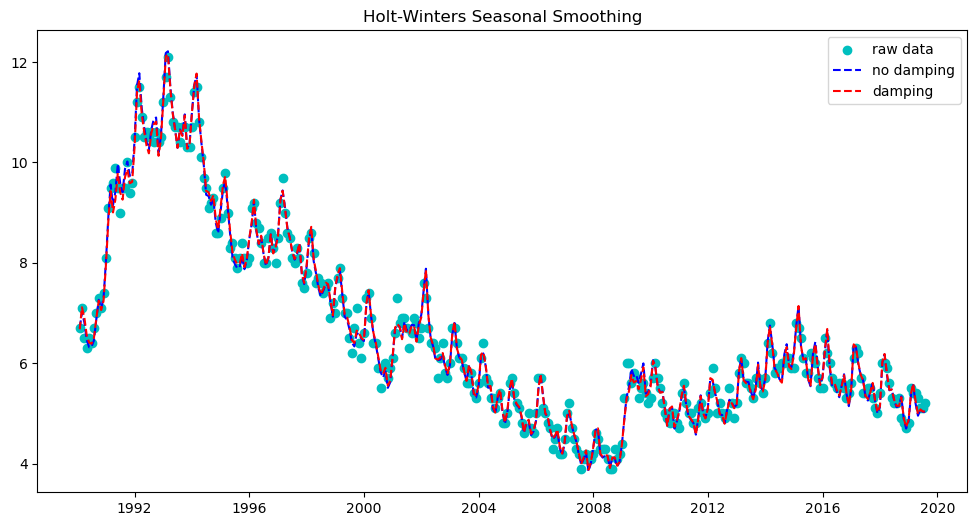

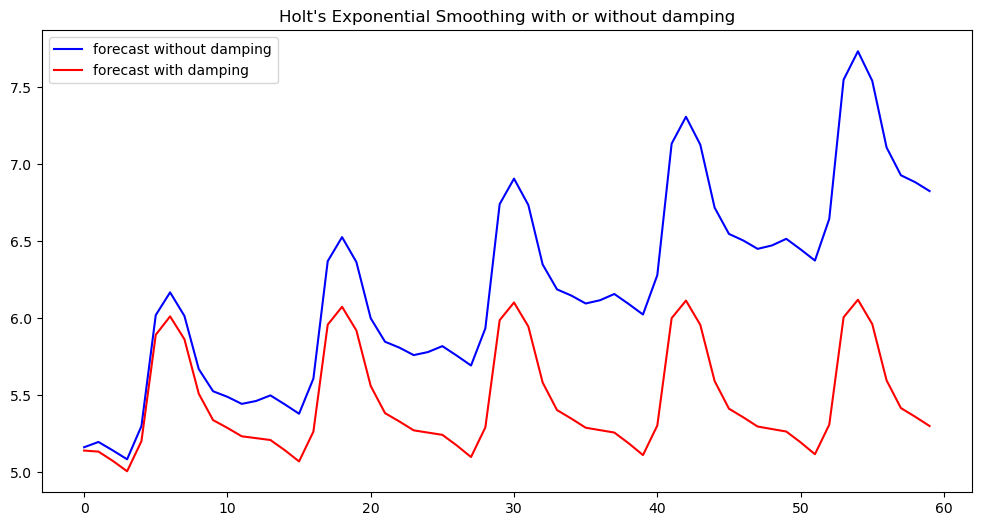

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df.index, df.unemp, color ='c', label='raw data');
ax.plot(df.index, fit_season_Holt.fittedvalues, linestyle='--', color='b', label="no damping")
ax.plot(df.index, fit_season_Damp.fittedvalues, linestyle='--', color='r', label="damping")
ax.legend();
ax.set_title("Holt-Winters Seasonal Smoothing");

fig2 = plt.subplots(figsize=(12, 6))
plt.plot(np.arange(0,60), fore_season_Holt, label="forecast without damping", color='b')
plt.plot(np.arange(0,60), fore_season_Damp, label="forecast with damping", color='r')
plt.title("Holt's Exponential Smoothing with or without damping")    
plt.legend();

### (c). Plotting them all
**Compare the forecasts to each other, and to the results obtained using decomposition tools from last week. Which method seems preferable here? Why?**

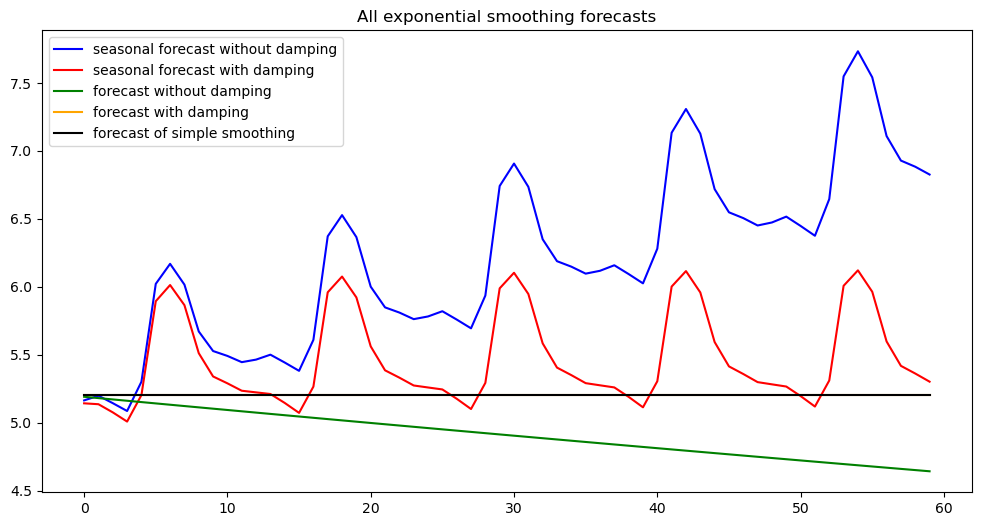

In [23]:
fig3 = plt.subplots(figsize=(12, 6))
plt.plot(np.arange(0,60), fore_season_Holt, label="seasonal forecast without damping", color='b')
plt.plot(np.arange(0,60), fore_season_Damp, label="seasonal forecast with damping"   , color='r')
plt.plot(np.arange(0,60), fore_Holt_2     , label="forecast without damping"       , color='g')
plt.plot(np.arange(0,60), fore_Damp_2     , label="forecast with damping"          , color='orange')
plt.plot(np.arange(0,60), fore_simple     , label="forecast of simple smoothing"     , color='k')
plt.title("All exponential smoothing forecasts")    
plt.legend();